🎯 Accuracy Titanic: 0.7063
📊 Matriz de Confusión:
[[67 13]
 [29 34]]

🌟 Importancia de predictores (Titanic):
Sex         0.557417
Pclass      0.229486
Age         0.113249
Fare        0.052018
SibSp       0.029507
Parch       0.018323
Embarked    0.000000
dtype: float64


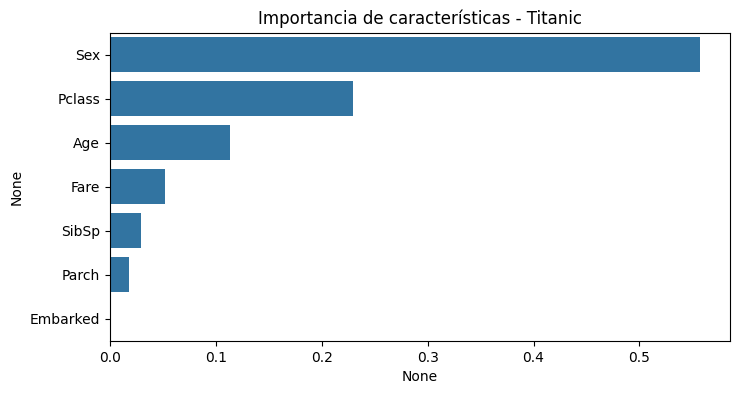

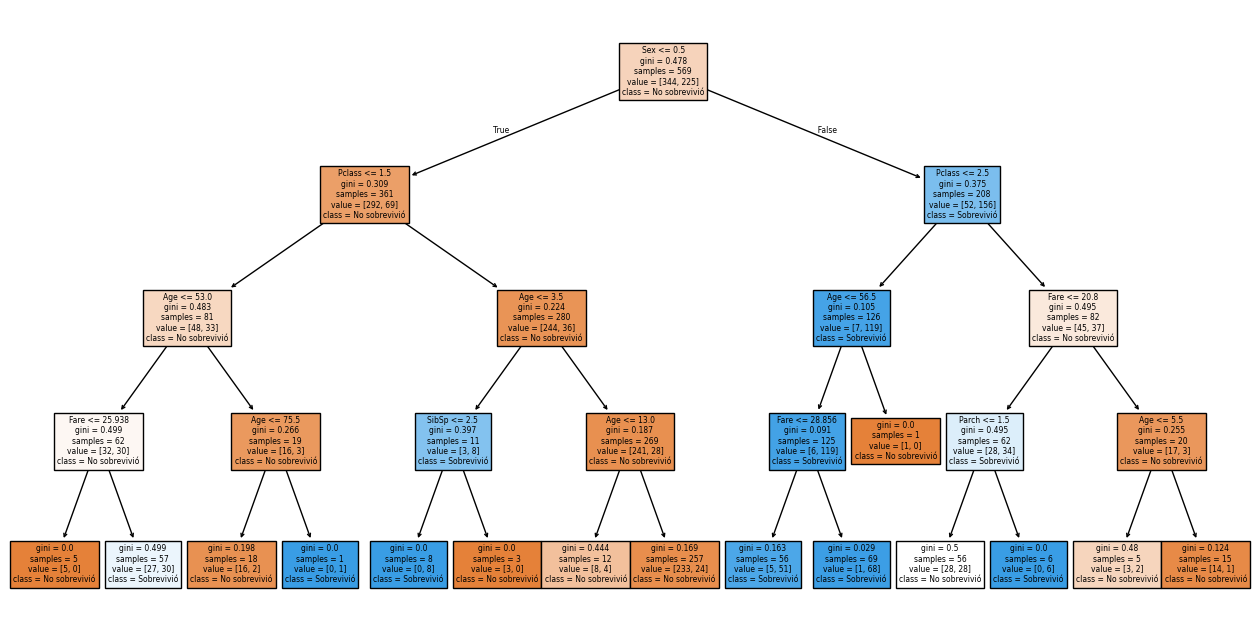


🧠 Mejores parámetros Titanic: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 5}
🎯 Mejor accuracy Titanic: 0.81895668374476


KeyError: 'median_house_value'

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
from sklearn import tree
import matplotlib.pyplot as plt
import seaborn as sns


titanic = pd.read_csv("/content/titanic-train.csv")

-
titanic = titanic[['Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
titanic.dropna(inplace=True)

titanic['Sex'] = titanic['Sex'].map({'male':0, 'female':1})
titanic['Embarked'] = titanic['Embarked'].map({'S':0, 'C':1, 'Q':2})

X_titanic = titanic.drop('Survived', axis=1)
y_titanic = titanic['Survived']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_titanic, y_titanic, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
clf.fit(X_train_t, y_train_t)

y_pred_t = clf.predict(X_test_t)
acc = accuracy_score(y_test_t, y_pred_t)

print("🎯 Accuracy Titanic:", round(acc, 4))
print("📊 Matriz de Confusión:")
print(confusion_matrix(y_test_t, y_pred_t))

importances_t = pd.Series(clf.feature_importances_, index=X_titanic.columns).sort_values(ascending=False)
print("\n🌟 Importancia de predictores (Titanic):")
print(importances_t)

plt.figure(figsize=(8,4))
sns.barplot(x=importances_t, y=importances_t.index)
plt.title("Importancia de características - Titanic")
plt.show()

plt.figure(figsize=(16,8))
tree.plot_tree(clf, feature_names=X_titanic.columns, class_names=["No sobrevivió","Sobrevivió"], filled=True)
plt.show()

params_t = {
    'max_depth':[3,4,5,6,7],
    'min_samples_split':[2,5,10],
    'criterion':['gini','entropy']
}
grid_t = GridSearchCV(DecisionTreeClassifier(random_state=42), params_t, cv=5)
grid_t.fit(X_train_t, y_train_t)

print("\n🧠 Mejores parámetros Titanic:", grid_t.best_params_)
print("🎯 Mejor accuracy Titanic:", grid_t.best_score_)



housing = pd.read_csv("/content/house_prices_large.csv")

housing = housing.select_dtypes(include=[np.number])
housing.dropna(inplace=True)

y_housing = housing['median_house_value']
X_housing = housing.drop('median_house_value', axis=1)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_housing, y_housing, test_size=0.2, random_state=42)

reg = DecisionTreeRegressor(criterion='friedman_mse', max_depth=6, random_state=42)
reg.fit(X_train_h, y_train_h)

y_pred_h = reg.predict(X_test_h)
rmse = np.sqrt(mean_squared_error(y_test_h, y_pred_h))

print("\n🏠 RMSE Housing:", round(rmse, 2))

importances_h = pd.Series(reg.feature_importances_, index=X_housing.columns).sort_values(ascending=False)
print("\n🌟 Importancia de predictores (Housing):")
print(importances_h)

plt.figure(figsize=(8,4))
sns.barplot(x=importances_h, y=importances_h.index)
plt.title("Importancia de características - Housing")
plt.show()

params_h = {
    'max_depth':[4,5,6,7,8,9],
    'min_samples_split':[2,5,10],
    'criterion':['squared_error','friedman_mse','absolute_error']
}
grid_h = GridSearchCV(DecisionTreeRegressor(random_state=42), params_h, cv=5)
grid_h.fit(X_train_h, y_train_h)

print("\n🧠 Mejores parámetros Housing:", grid_h.best_params_)
print("📉 Mejor RMSE Housing:", np.sqrt(-grid_h.best_score_))
